# Matplotlib example 2: Life expectancy
We use the data about [life expectancy at birth from GapMinder](https://www.gapminder.org/data/).

In [1]:
import pandas as pd

In [22]:
df = pd.read_csv('../datasets/lex.csv')
df

,geo,name,1800,1801,1802,1803,1804,1805,1806,1807,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,afg,Afghanistan,28.21,28.20,28.19,28.18,28.17,28.16,28.15,28.14,...,75.92,76.07,76.21,76.36,76.50,76.65,76.80,76.95,77.10,77.25
1,ago,Angola,26.98,26.98,26.98,26.98,26.98,26.98,26.98,26.98,...,75.75,75.87,75.99,76.12,76.26,76.39,76.52,76.65,76.79,76.91
2,alb,Albania,35.40,35.40,35.40,35.40,35.40,35.40,35.40,35.40,...,88.93,89.05,89.17,89.28,89.40,89.51,89.62,89.73,89.84,89.95
3,and,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,91.02,91.14,91.25,91.36,91.47,91.59,91.71,91.82,91.93,92.04
4,are,UAE,30.70,30.70,30.70,30.70,30.70,30.70,30.70,30.70,...,83.67,83.78,83.90,84.02,84.14,84.24,84.35,84.47,84.58,84.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,wsm,Samoa,25.40,25.40,25.40,25.40,25.40,25.40,25.40,25.40,...,81.11,81.25,81.38,81.51,81.64,81.77,81.90,82.02,82.15,82.27
190,yem,Yemen,23.39,23.39,23.39,23.39,23.39,23.39,23.39,23.39,...,80.59,80.76,80.92,81.08,81.25,81.40,81.58,81.75,81.92,82.08
191,zaf,South Africa,33.50,33.50,33.50,33.50,33.50,33.50,33.50,33.50,...,74.02,74.15,74.29,74.42,74.55,74.69,74.82,74.96,75.09,75.24
192,zmb,Zambia,32.60,32.60,32.60,32.60,32.60,32.60,32.60,32.60,...,73.29,73.42,73.55,73.69,73.81,73.95,74.08,74.22,74.35,74.48


The data is in *wide* format. We convert it into *long* format with `melt`.

In [23]:
df2 = df.drop('geo',axis=1).melt(id_vars='name',var_name='year',value_name='life expectancy at birth')
df2

,name,year,life expectancy at birth
0,Afghanistan,1800,28.21
1,Angola,1800,26.98
2,Albania,1800,35.40
3,Andorra,1800,NaN
4,UAE,1800,30.70
...,...,...,...
58389,Samoa,2100,82.27
58390,Yemen,2100,82.08
58391,South Africa,2100,75.24
58392,Zambia,2100,74.48


We select only the Nordic countries.

In [24]:
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
df2.query('name in @nordic_countries')

,name,year,life expectancy at birth
47,Denmark,1800,37.41
56,Finland,1800,36.57
81,Iceland,1800,42.85
129,Norway,1800,37.92
164,Sweden,1800,32.16
...,...,...,...
58247,Denmark,2100,91.13
58256,Finland,2100,91.97
58281,Iceland,2100,94.02
58329,Norway,2100,92.63


We now plot the life expectancies with different colors and add a legend.
We can convert the string year into a datetime with `pd.todatetime`.

In [25]:
import matplotlib.pyplot as plt

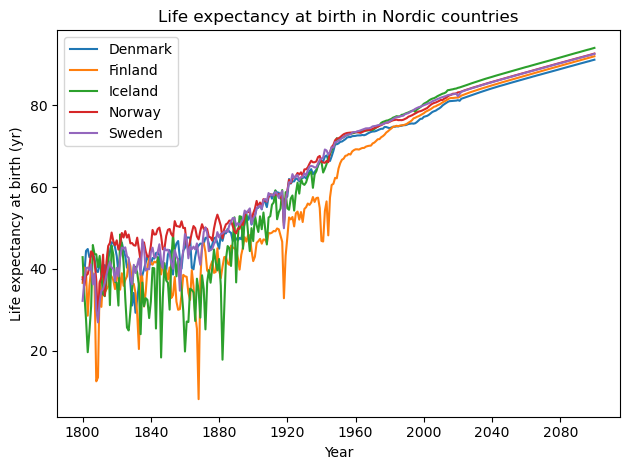

In [30]:
for country in nordic_countries:
    df3 = df2.query('name == @country')
    plt.plot(pd.to_datetime(df3['year']),df3['life expectancy at birth'],label=country)
plt.legend()
plt.xlabel('Year')
plt.ylabel('Life expectancy at birth (yr)')
plt.title('Life expectancy at birth in Nordic countries')
plt.tight_layout()